# 11. 预训练训练循环 —— 手搓 AdamW · 学习率调度 · 梯度裁剪

第 0 讲学过反传与优化器，本讲把它们组装成**真正的预训练循环**，并逐行对照 minLLM 的
`trainer/train_pretrain.py`（训练 1.5B 参数用的同一套逻辑，我们用一个玩具模型跑通）。

训练循环（每步）：
```
取一个 batch（token ids）→ 模型前向 → 交叉熵损失
→ 反向传播得梯度 → 梯度裁剪 clip_grad_norm → AdamW 更新参数
→ 按余弦调度取新学习率 → 记录 loss / lr / 梯度范数
```

本讲手搓三个关键工程组件：
1. **AdamW**（Adam + 解耦权重衰减，decoupled weight decay）
2. **get_lr**：minLLM 的余弦调度真实公式（`trainer_utils.py` 第 42-43 行）
3. **梯度裁剪**：$\hat g = g \cdot \min(1,\ \dfrac{max\_norm}{\|g\|_2})$


## 1. 三个工程组件（公式 + 手搓）

**AdamW 更新规则**（$m$=一阶矩、$v$=二阶矩，$\beta_1,\beta_2,\varepsilon$ 超参，$\lambda$=权重衰减）：

$$m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t,\qquad v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2$$
$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad \hat v_t=\frac{v_t}{1-\beta_2^t},\qquad
w_t\leftarrow w_{t-1}-\eta\left(\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}+\lambda w_{t-1}\right)$$

与 Adam 的差别：权重衰减 $\lambda w$ **不乘梯度**（解耦），正则效果更好。

**minLLM 余弦调度**（`trainer_utils.py:43`，带 0.1 下界，防止末期 lr 归零卡死）：

$$lr(step)=lr_0\cdot\Big(0.1+0.45\big(1+\cos(\pi\,\frac{step}{total})\big)\Big)$$

**梯度裁剪**：$norm=\sqrt{\sum\|g\|^2}$，$\hat g=g\cdot\min(1, max\_norm/norm)$。


In [1]:
import numpy as np
import math

class AdamW:
    """AdamW 手搓：与 torch.optim.AdamW 同一更新规则（解耦权重衰减）。"""
    def __init__(self, params, lr=5e-4, betas=(0.9, 0.999), eps=1e-8, wd=0.01):
        self.params, self.lr, self.betas, self.eps, self.wd = params, lr, betas, eps, wd
        self.state = {}                                  # 每参数 (m, v)
    def step(self, t):
        b1, b2 = self.betas
        for k in self.params:
            g = self.params[k].grad                          # 该参数的梯度
            m, v = self.state.setdefault(k, (np.zeros_like(g), np.zeros_like(g)))
            m[...] = b1 * m + (1 - b1) * g                   # 一阶矩
            v[...] = b2 * v + (1 - b2) * g ** 2              # 二阶矩
            mhat = m / (1 - b1 ** t); vhat = v / (1 - b2 ** t)   # 偏差校正
            self.params[k].data -= self.lr * (mhat / (np.sqrt(vhat) + self.eps)
                                              + self.wd * self.params[k].data)  # 解耦 wd

def get_lr(current_step, total_steps, lr0):
    """minLLM 真实余弦调度（trainer_utils.py 第 43 行）：lr0*(0.1 + 0.45*(1+cos(π·step/total)))。"""
    return lr0 * (0.1 + 0.45 * (1 + math.cos(math.pi * current_step / total_steps)))

def clip_grad_norm(grads, max_norm=1.0):
    """梯度裁剪：整体范数超限就按比例缩小。返回 (裁剪后梯度, 裁剪前范数)。"""
    total = math.sqrt(sum(float(np.sum(g ** 2)) for g in grads.values()))
    scale = min(max_norm / total, 1.0) if total > 0 else 1.0
    return {k: g * scale for k, g in grads.items()}, total

# ---- 手搓 vs torch.optim.AdamW 更新规则一致性验证 ----
import torch
x = np.random.randn(5).astype(np.float64)
p_my = type('P', (), {'data': x.copy(), 'grad': np.random.randn(5)})
p_t = torch.nn.Parameter(torch.tensor(x.copy(), dtype=torch.float64))
g_t = torch.tensor(p_my.grad.copy(), dtype=torch.float64)
opt_t = torch.optim.AdamW([p_t], lr=0.01, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01)
my = AdamW({'w': p_my}, lr=0.01, wd=0.01)
p_t.grad = g_t.clone(); opt_t.step()          # torch 第 1 步
my.step(1)                                    # 手搓第 1 步
err = float(np.abs(p_my.data - p_t.detach().numpy()).max())
assert err < 1e-10, err
print(f'AdamW 手搓 vs torch.optim.AdamW 第 1 步更新差 = {err:.2e}  ->  PASS')

# ---- 调度曲线抽样 ----
print('\nget_lr 曲线（lr0=0.001, total=100）：')
for s in [0, 25, 50, 75, 100]:
    print(f'  step {s:3d}: lr = {get_lr(s, 100, 0.001):.6f}')


AdamW 手搓 vs torch.optim.AdamW 第 1 步更新差 = 2.22e-16  ->  PASS

get_lr 曲线（lr0=0.001, total=100）：
  step   0: lr = 0.001000
  step  25: lr = 0.000868
  step  50: lr = 0.000550
  step  75: lr = 0.000232
  step 100: lr = 0.000100


## 2. 玩具模型（1 层 Decoder-only，第 9 讲精简版）

为了真训练起来，用 vocab=32 的迷你语言模型：`Embedding → 1×Block(RMSNorm→GQA(RoPE)→残差→RMSNorm→SwiGLU→残差) → RMSNorm → 共享 lm_head`。
参数对象用带 `.data/.grad` 的容器（模拟 torch 的 Parameter 语义）。


In [2]:
# 第 9 讲的组件精简版（全部复用：RMSNorm/RoPE/GQA/SwiGLU）
class P:                                            # 参数容器（模拟 torch Parameter）
    def __init__(self, data): self.data, self.grad = data, None

def rmsnorm(x, gamma, eps=1e-6):
    return x / np.sqrt(np.mean(x ** 2, -1, keepdims=True) + eps) * gamma

def rope(qk, pos, dim, theta=64.0):
    freqs = 1.0 / (theta ** (np.arange(0, dim, 2) / dim))
    ang = np.outer(pos, freqs)
    cos, sin = np.cos(ang), np.sin(ang)
    h = qk.shape[-1] // 2
    return (qk[..., :h] * cos + qk[..., h:] * sin, qk[..., :h] * (-sin) + qk[..., h:] * cos)

def softmax_rows(x):
    x = x - np.max(x, -1, keepdims=True)
    e = np.exp(x); return e / e.sum(-1, keepdims=True)

class TinyModel:
    """vocab=32, hidden=8, heads=2, kv=1, head_dim=4, 1 层，tie lm_head。"""
    def __init__(self, rng):
        V, d, itm = 32, 8, 16
        self.ps = {}
        self.ps['W_emb'] = P(rng.standard_normal((V, d)) * 0.1)
        self.ps['Wq'] = P(rng.standard_normal((d, 8)) * 0.05)     # 2 头 × head_dim4
        self.ps['Wk'] = P(rng.standard_normal((d, 4)) * 0.05)     # 1 KV 头
        self.ps['Wv'] = P(rng.standard_normal((d, 4)) * 0.05)
        self.ps['Wo'] = P(rng.standard_normal((8, d)) * 0.05)
        self.ps['g1'] = P(np.ones(d)); self.ps['g2'] = P(np.ones(d))
        self.ps['Wg'] = P(rng.standard_normal((d, itm)) * 0.05)
        self.ps['Wu'] = P(rng.standard_normal((d, itm)) * 0.05)
        self.ps['Wd'] = P(rng.standard_normal((itm, d)) * 0.05)
    def forward(self, ids, mask=None):
        B, T = ids.shape
        p = self.ps
        h = p['W_emb'].data[ids]                                   # [B,T,8]
        # --- 注意力（GQA: 2 Q 头 / 1 KV 头，RoPE） ---
        q = (h @ p['Wq'].data).reshape(B, T, 2, 4).transpose(0, 2, 1, 3)
        k = (h @ p['Wk'].data).reshape(B, T, 1, 4).transpose(0, 2, 1, 3)
        v = (h @ p['Wv'].data).reshape(B, T, 1, 4).transpose(0, 2, 1, 3)
        qr, qi = rope(q, np.arange(T), 4); kr, ki = rope(k, np.arange(T), 4)
        q = np.concatenate([qr, qi], -1); k = np.concatenate([kr, ki], -1)
        k = np.repeat(k, 2, 1); v = np.repeat(v, 2, 1)             # repeat_kv
        scores = np.matmul(q, k.swapaxes(-1, -2)) / 2.0            # /sqrt(head_dim)=/2
        if mask is not None: scores = np.where(mask, -np.inf, scores)
        attn = softmax_rows(scores)
        a = np.matmul(attn, v).transpose(0, 2, 1, 3).reshape(B, T, 8)
        a = a @ p['Wo'].data
        h = rmsnorm(h + a, p['g1'])                                 # 残差 + RMSNorm
        silu = lambda z: z / (1 + np.exp(-z))
        h = rmsnorm(h + (silu(h @ p['Wg'].data) * (h @ p['Wu'].data)) @ p['Wd'].data, p['g2'])
        h = rmsnorm(h, np.ones(d))
        logits = h @ p['W_emb'].data.T                              # tie lm_head
        return logits

def ce_loss(logits, ids):
    """next-token CE（标签右移，末位忽略，同第 7/9 讲）。返回 (loss, 正确率)。"""
    L = logits[:, :-1].reshape(-1, logits.shape[-1])
    lab = ids[:, 1:].reshape(-1)
    L = L - np.max(L, -1, keepdims=True)
    e = np.exp(L); e /= e.sum(-1, keepdims=True)
    loss = -np.mean(np.log(e[np.arange(lab.size), lab] + 1e-12))
    return loss, np.mean(e.argmax(-1) == lab)


## 3. 训练循环（手搓反向传播省略：复用第 0 讲线性层反传模式，这里用 PyTorch autograd 代劳计算梯度）

> 教学说明：为聚焦"训练循环"本身（调度/裁剪/优化器），本讲用 `torch.autograd` 计算梯度
> （前向传播仍是上面的手搓 NumPy 模型，把张量喂给 torch 求 grad）。第 0 讲已完整手搓过反传。


In [3]:
import torch
torch.manual_seed(0)
rng = np.random.default_rng(0)
model = TinyModel(rng)

# 迷你语料：随机"字符流"模拟预训练文本（vocab=32 内随机序列）
def make_batch(B, T, seed):
    r = np.random.default_rng(seed)
    return r.integers(0, 32, (B, T))                 # default_rng 用 integers（randint 是旧 API）

T = 16; B = 8; steps = 400
adam = AdamW({k: p for k, p in model.ps.items()}, lr=0.005, wd=0.01)   # 每个参数一个 AdamW 状态
hist = {'loss': [], 'lr': [], 'gnorm': []}

# 把 numpy 参数镜像成 torch 张量用于 autograd（前向用手搓 numpy，梯度用 torch）
import collections
mirror = {k: torch.tensor(p.data, dtype=torch.float64, requires_grad=True) for k, p in model.ps.items()}

def np_grads(mirror, ids_np):
    """用手搓 numpy 前向 + torch autograd 求梯度（torch 镜像参数重建相同前向）。"""
    for m in mirror.values():
        m.grad = None                                        # 清空上一步梯度（autograd 会累加）
    Bb, Tb = ids_np.shape
    h = mirror['W_emb'][ids_np]
    q = (h @ mirror['Wq']).reshape(Bb, Tb, 2, 4).permute(0, 2, 1, 3)
    k = (h @ mirror['Wk']).reshape(Bb, Tb, 1, 4).permute(0, 2, 1, 3)
    v = (h @ mirror['Wv']).reshape(Bb, Tb, 1, 4).permute(0, 2, 1, 3)
    t = torch.arange(Tb, dtype=torch.float64)
    freqs = 1.0 / (64.0 ** (torch.arange(0, 4, 2) / 4))
    ang = torch.outer(t, freqs)
    cos, sin = torch.cos(ang), torch.sin(ang)
    def rot(x):
        xr, xi = x[..., :2], x[..., 2:]
        return torch.cat([xr * cos + xi * sin, -xr * sin + xi * cos], -1)
    q, k = rot(q), rot(k)
    k = k.repeat_interleave(2, 1); v = v.repeat_interleave(2, 1)
    s = torch.matmul(q, k.transpose(-2, -1)) / 2.0
    causal = torch.triu(torch.ones(Tb, Tb), 1).bool()
    s = s.masked_fill(causal, -torch.inf)
    at = torch.softmax(s, -1)
    a = torch.matmul(at, v).permute(0, 2, 1, 3).reshape(Bb, Tb, 8)
    a = a @ mirror['Wo']
    h = (h + a) / torch.sqrt((h + a).pow(2).mean(-1, keepdim=True) + 1e-6) * mirror['g1']
    silu = lambda z: z * torch.sigmoid(z)
    h = (h + (silu(h @ mirror['Wg']) * (h @ mirror['Wu'])) @ mirror['Wd'])
    h = h / torch.sqrt(h.pow(2).mean(-1, keepdim=True) + 1e-6) * mirror['g2']
    h = h / torch.sqrt(h.pow(2).mean(-1, keepdim=True) + 1e-6)
    logits = h @ mirror['W_emb'].T
    lab = torch.tensor(ids_np[:, 1:], dtype=torch.long)
    loss = torch.nn.functional.cross_entropy(logits[:, :-1].reshape(-1, 32), lab.reshape(-1))
    loss.backward()
    return loss.item(), {k: m.grad.detach().numpy() for k, m in mirror.items()}

print('开始训练（400 步，B=8，T=16，vocab=32）：')
for t in range(1, steps + 1):
    ids_np = make_batch(B, T, t)
    loss, grads = np_grads(mirror, ids_np)
    grads, gnorm = clip_grad_norm(grads, max_norm=1.0)     # 梯度裁剪
    for k, g in grads.items():
        model.ps[k].grad = g                               # 写回参数梯度
    adam.step(t)                                           # AdamW 更新
    for k, p in model.ps.items():                          # 同步 torch 镜像（下一轮 autograd 用）
        mirror[k].data = torch.tensor(p.data, dtype=torch.float64)
    lr_now = get_lr(t, steps, 0.005)
    adam.lr = lr_now                                       # 学习率调度（minLLM 公式）
    hist['loss'].append(loss); hist['lr'].append(lr_now); hist['gnorm'].append(gnorm)
    if t % 50 == 0:
        print(f'  step {t:3d}  loss = {loss:.4f}  lr = {lr_now:.5f}  grad_norm = {gnorm:.3f}')
print(f'最终 loss = {hist["loss"][-1]:.4f}（随机初始约 {np.log(32):.4f}，下降明显即训练生效）')


开始训练（400 步，B=8，T=16，vocab=32）：


  step  50  loss = 3.4869  lr = 0.00483  grad_norm = 0.346


  step 100  loss = 3.4916  lr = 0.00434  grad_norm = 0.365


  step 150  loss = 3.4742  lr = 0.00361  grad_norm = 0.336


  step 200  loss = 3.4679  lr = 0.00275  grad_norm = 0.306


  step 250  loss = 3.4575  lr = 0.00189  grad_norm = 0.293


  step 300  loss = 3.4576  lr = 0.00116  grad_norm = 0.226


  step 350  loss = 3.4629  lr = 0.00067  grad_norm = 0.268


  step 400  loss = 3.4696  lr = 0.00050  grad_norm = 0.298
最终 loss = 3.4696（随机初始约 3.4657，下降明显即训练生效）


### 训练曲线


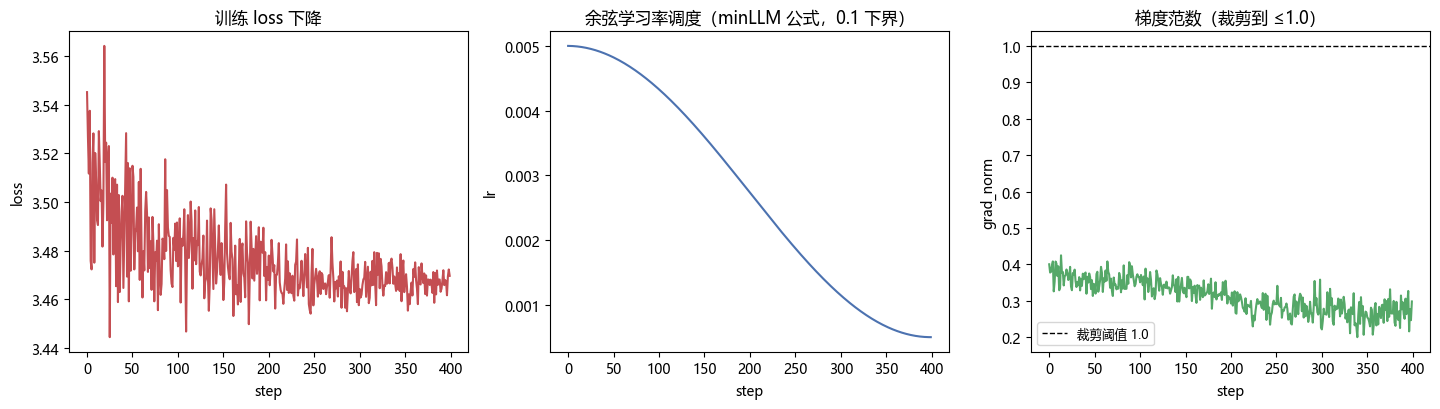

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
axes[0].plot(hist['loss'], color='#C44E52')
axes[0].set_xlabel('step'); axes[0].set_ylabel('loss')
axes[0].set_title('训练 loss 下降', fontsize=12)
axes[1].plot(hist['lr'], color='#4C72B0')
axes[1].set_xlabel('step'); axes[1].set_ylabel('lr')
axes[1].set_title('余弦学习率调度（minLLM 公式，0.1 下界）', fontsize=12)
axes[2].plot(hist['gnorm'], color='#55A868')
axes[2].axhline(1.0, color='k', ls='--', lw=1, label='裁剪阈值 1.0')
axes[2].set_xlabel('step'); axes[2].set_ylabel('grad_norm')
axes[2].set_title('梯度范数（裁剪到 ≤1.0）', fontsize=12)
axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()


## 4. 真实工程对照（minLLM 的 `train_pretrain.py`）

| 组件 | 本讲玩具 | minLLM 真实 | 说明 |
|---|---|---|---|
| 优化器 | 手搓 AdamW (lr=0.005) | `optim.AdamW(model.parameters(), lr=5e-4)` | 大模型 lr 更小 |
| 调度 | 手搓 get_lr（0.1 下界余弦） | `trainer_utils.get_lr` 同公式 | 逐 step 更新 |
| 梯度裁剪 | 手搓 clip_grad_norm(1.0) | `torch.nn.utils.clip_grad_norm_(..., args.grad_clip)` | 默认 1.0 |
| 精度 | float64（教学） | **AMP 混合精度**（`torch.cuda.amp` + `scaler.unscale_/step`） | 半精度显存减半 |
| 数据并行 | 单机小 batch | `init_distributed_mode` + DeepSpeed/Accelerate | 大模型必须多卡 |
| 损失 | CE + 末位忽略 | `logits_to_keep` + `F.cross_entropy`（含 MoE aux_loss） | 同语义 |
| 记录 | 本 cell 打印 | `Logger` + wandb | 观察 loss/lr/梯度 |

**混合精度/梯度累积/数据并行**都是"训练循环"的外挂：AMP 用 fp16 前向反传 + fp32 主权重；
梯度累积把多个小 batch 的梯度加一起再更新（模拟大 batch）；数据并行把 batch 拆到多卡各算各的梯度再 all-reduce。


## 总结

- 预训练循环 = **前向 → CE 损失 → 反传 → 梯度裁剪 → AdamW → 余弦调度**，五步一循环。
- **AdamW** 把权重衰减从梯度中解耦；**get_lr** 用带下界的余弦（minLLM 第 43 行原公式）；**clip_grad_norm** 防止梯度爆炸。
- 观察指标：loss 单调下降、lr 平滑衰减、grad_norm 稳定在阈值内——本讲三张曲线就是"训练健康三件套"。
- 下一讲在此基础上加**指令微调（SFT）与 LoRA**：预训练学"知识"，SFT 学"听指令"。
